모델 배포 개론 04  
Last modified : 2026.06   
작성 : 박광석 (모두의연구소)  
수정 : 김지성, 박기웅 (모두의연구소)

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# Colab의 nest_asyncio 방식 대신, macOS에서도 안정적인 표준 asyncio 루프를 사용합니다.
print("도우미 로딩 중...", flush=True)

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, signal
from pathlib import Path

print("uvicorn import 중...", flush=True)
import uvicorn
print("uvicorn 준비 완료", flush=True)

cwd = Path.cwd()
if (cwd / "DP04.ipynb").exists() or (cwd / "app").exists():
    pass
elif (cwd / "DP04" / "DP04.ipynb").exists():
    os.chdir(cwd / "DP04")
elif cwd.name == "notebooks" and (cwd.parent / "app").exists():
    os.chdir(cwd.parent)

for _d in ("app", "models", "data", "frontend"):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def _pids_on_port(port):
    """해당 포트를 LISTEN 중인 프로세스 PID 목록을 반환합니다."""
    try:
        out = subprocess.check_output(
            ["lsof", "-nP", f"-iTCP:{port}", "-sTCP:LISTEN", "-t"],
            text=True,
            stderr=subprocess.DEVNULL,
            timeout=2,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, subprocess.TimeoutExpired):
        return []
    pids = []
    for line in out.split():
        try:
            pid = int(line)
        except ValueError:
            continue
        if pid != os.getpid():
            pids.append(pid)
    return pids

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다. 같은 포트의 다른 프로세스도 종료합니다."""
    entry = _SERVERS.pop(port, None)
    if entry:
        server, thread = entry
        server.should_exit = True
        for _ in range(50):
            if not thread.is_alive():
                break
            time.sleep(0.1)
    for pid in _pids_on_port(port):
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
    for _ in range(50):
        if not _port_open("127.0.0.1", port):
            break
        time.sleep(0.1)

def serve_in_thread(app, host="127.0.0.1", port=8000, log_level="warning"):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(":")[0], None)
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    if _port_open(host, port):
        print(f"포트 {port}가 아직 사용 중입니다. 다른 서버를 종료한 뒤 다시 실행하세요.")
        return None
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop="asyncio")
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        if sys.platform == "win32":
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if getattr(server, "started", False) and _port_open(host, port):
            print(f"서버 실행됨: http://{host}:{port}")
            return server
        if not thread.is_alive():
            break
        time.sleep(0.25)
    print("서버가 시작되지 않았습니다. 위 로그를 확인하세요.")
    return server

print("서버 도우미 준비 완료 (serve_in_thread, stop_server)", flush=True)
print(f"작업 디렉터리: {Path.cwd()}", flush=True)

도우미 로딩 중...
uvicorn import 중...
uvicorn 준비 완료
서버 도우미 준비 완료 (serve_in_thread, stop_server)
작업 디렉터리: /Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP04


> **로컬(Mac) 환경 준비**
>
> Colab이 아니라면 아래를 한 번만 준비하면 됩니다.
>
> ```bash
> cd 06_Deployment/DP04
> python3.12 -m venv .venv
> source .venv/bin/activate
> pip install -r requirements.txt
> python -m ipykernel install --user --name dp04-venv --display-name "DP04 .venv"
> ```
>
> Cursor에서 커널을 **DP04 .venv** 로 선택한 뒤, 위 도우미 셀부터 순서대로 실행하세요.
> 포트 8000이 다른 앱에 점유되어 있으면 `serve_in_thread`가 자동으로 정리합니다.
> Streamlit은 노트북 iframe 대신 브라우저(`http://localhost:8501`)에서 여는 것이 안정적입니다.
> MNIST 가중치는 `../DP02/models/mnist_state_dict.pth` 가 있으면 학습 없이 복사합니다.


## 학습페이지에 있는 준비물을 적절한 위치에 업로드해주세요!

# Day 4 — Streamlit & System Architecture
## 1. Streamlit 소개: Python만으로 만드는 웹 UI

---

> **학습 목표**
> - Streamlit이 무엇이고, 왜 ML 엔지니어에게 유용한지 이해합니다.
> - Streamlit의 실행 방식(스크립트 재실행 모델)을 파악합니다.
> - 최소한의 코드로 Streamlit 앱을 실행해 봅니다.

### 1.0 사전 준비

> 이 섹션은 Streamlit 앱 파일을 직접 생성(`%%writefile`)하므로 이전 Day의 파일에 의존하지 않습니다.
> 아래 셀에서 필요한 패키지와 폴더만 확인합니다.

In [2]:
# Colab이 아니라면 requirements.txt 설치분이 있으면 건너뜁니다.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("streamlit") is None:
    print("Streamlit 설치 중...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "streamlit"])
else:
    import streamlit
    print(f"Streamlit 이미 설치됨: {streamlit.__version__}")

Streamlit 이미 설치됨: 1.61.1


In [3]:
import os
os.makedirs("frontend", exist_ok=True)

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("streamlit") is None:
    print("Streamlit 미설치 → 지금 설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "streamlit"])

import streamlit
print(f"✅ Streamlit: {streamlit.__version__}")

✅ Streamlit: 1.61.1


---

### 1.1 지금까지의 흐름 복습

Day 1~3에서 완성한 것을 정리합니다.

```
Day 1: 모델 학습 → 직렬화 → 파일 저장
Day 2: FastAPI로 추론 API 구축 → Swagger UI에서 테스트
Day 3: 비동기 처리, 에러 핸들링, 로깅으로 안정성 강화
```

API는 완성되었습니다. Swagger UI에서 테스트도 됩니다.
그런데 이 서비스를 **비개발자**에게 전달한다면 어떻게 될까요?

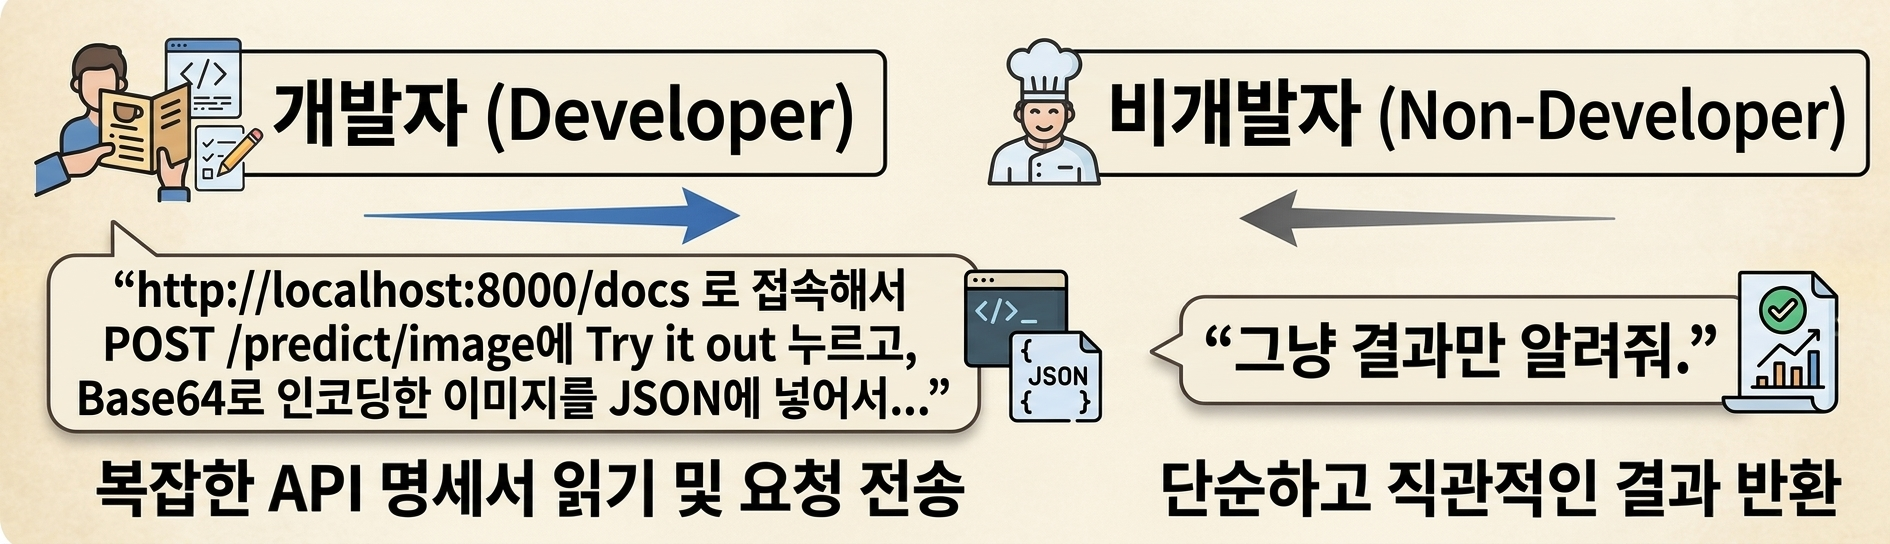


사용자에게 필요한 것은 **이미지를 드래그 앤 드롭하면 결과가 나오는 화면**입니다.  
오늘은 그 화면을 만듭니다.

### 1.2 Streamlit이란 무엇입니까?

Streamlit은 **Python 스크립트만으로 웹 애플리케이션을 만드는 프레임워크**입니다.

```
일반적인 웹 UI 개발:
  HTML + CSS + JavaScript + React/Vue + 빌드 설정 + ...
  → 프론트엔드 전문 지식 필요
  → 수주일의 개발 기간

Streamlit:
  Python 스크립트 하나
  → 프론트엔드 지식 불필요
  → 수십 분이면 동작하는 UI 완성
```

ML 엔지니어에게 Streamlit이 특히 유용한 이유:

```
- 모델 데모를 빠르게 만들어 팀/고객에게 보여줄 수 있습니다.
- 내부 도구(데이터 시각화, 모니터링 대시보드)를 직접 만들 수 있습니다.
- Python만 알면 되므로, 프론트엔드 개발자 없이도 프로토타입이 가능합니다.
- 이 과정의 프로젝트(Day 5, Day 7)에서 프론트엔드로 사용합니다.
```

### 1.3 Streamlit의 실행 모델: 스크립트 재실행

Streamlit의 동작 방식은 일반적인 웹 프레임워크와 다릅니다.
이것을 먼저 이해해야 이후 코드가 자연스럽게 읽힙니다.

```
[일반적인 웹 프레임워크]
  서버 시작 → 사용자 이벤트(클릭, 입력) → 해당 이벤트 핸들러만 실행

[Streamlit]
  사용자 이벤트(클릭, 입력) → 스크립트 전체를 위에서 아래로 다시 실행
```

즉, 사용자가 버튼을 누르거나 입력을 바꿀 때마다 **파이썬 스크립트가 처음부터 끝까지 다시 실행**됩니다.

```
app.py 실행 (1차)
─────────────────
  1행: st.title("...")        → 제목 렌더링
  2행: name = st.text_input() → 입력 위젯 렌더링 (값: "")
  3행: st.write(f"안녕, {name}") → "안녕, " 출력

사용자가 이름을 입력 → "홍길동"

app.py 실행 (2차 — 전체 재실행)
─────────────────
  1행: st.title("...")        → 제목 렌더링
  2행: name = st.text_input() → 입력 위젯 렌더링 (값: "홍길동")
  3행: st.write(f"안녕, {name}") → "안녕, 홍길동" 출력
```

> 이 동작 방식 때문에 **무거운 작업(모델 로드 등)을 매번 재실행하면 느려집니다.**
> 이 문제를 해결하는 `st.cache_resource`는 섹션 2에서 다룹니다.

### 1.4 실습: 첫 번째 Streamlit 앱

> ⚠️ **Streamlit은 주피터 노트북 안에서 직접 실행할 수 없습니다.**
>
> Streamlit은 독립적인 웹 서버로 동작하므로, `.py` 파일로 작성한 뒤
> 터미널에서 `streamlit run` 명령어로 실행합니다.
>
> 주피터 노트북에서는 `%%writefile`로 파일을 생성하고,
> `!streamlit run`으로 실행하는 방식을 사용합니다.

In [4]:
%%writefile frontend/app_hello.py
"""
Day 4 - 첫 번째 Streamlit 앱
"""
import streamlit as st

# 페이지 설정
st.set_page_config(
    page_title="My First Streamlit App",
    page_icon="🤖",
    layout="centered",
)

# 제목
st.title("🤖 나의 첫 Streamlit 앱")
st.write("Python 코드만으로 이 화면이 만들어졌습니다.")

# 구분선
st.divider()

# 텍스트 입력
name = st.text_input("이름을 입력하세요:", placeholder="홍길동")

# 조건부 출력
if name:
    st.success(f"안녕하세요, {name}님! 환영합니다. 🎉")
else:
    st.info("위에 이름을 입력해 보세요.")

# 버튼
if st.button("날짜 확인"):
    from datetime import datetime
    now = datetime.now().strftime("%Y년 %m월 %d일 %H시 %M분")
    st.write(f"현재 시각: {now}")

Overwriting frontend/app_hello.py


#### 실행 방법

```bash
# 터미널에서 실행 (별도 터미널을 열거나, 노트북에서 !로 실행)
# 주의: !로 실행하면 노트북 셀이 블로킹되므로, 별도 터미널 권장

# 로컬 환경:
streamlit run frontend/app_hello.py --server.port 8501

# Colab 환경:
# !streamlit run frontend/app_hello.py --server.port 8501 &
# (백그라운드 실행 후 ngrok 또는 localtunnel로 외부 접속)
```

> 실행하면 브라우저가 자동으로 열리며 `http://localhost:8501` 에 앱이 표시됩니다.
> 이름을 입력하고, 버튼을 눌러보세요.
> **Python 코드 17줄로 인터랙티브한 웹 페이지**가 만들어진 것입니다.

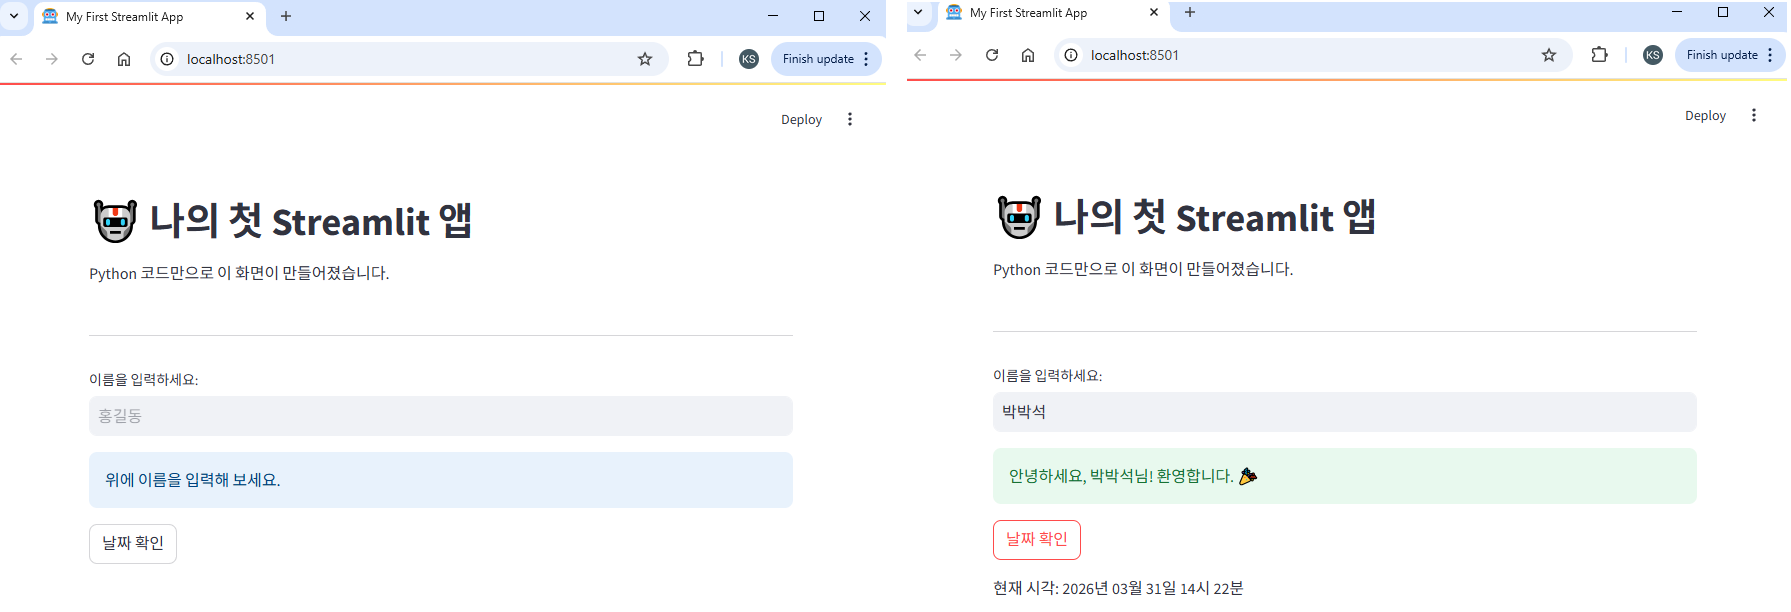

```python
# 노트북에서 백그라운드로 실행하는 방법 (선택)
import subprocess, time

proc = subprocess.Popen(
    ["streamlit", "run", "frontend/app_hello.py", "--server.port", "8501"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
time.sleep(3)
print("✅ Streamlit 앱 실행 중: http://localhost:8501")
print("   브라우저에서 위 주소로 접속하세요.")

# Colab:
# from google.colab import output
# output.serve_kernel_port_as_iframe(8501)
```

### 1.5 코드 해부: 한 줄씩 이해하기

```python
import streamlit as st
```

Streamlit의 모든 기능은 `st` 모듈을 통해 접근합니다.

```python
st.set_page_config(page_title="...", page_icon="🤖", layout="centered")
```

페이지 설정입니다. 브라우저 탭 제목, 아이콘, 레이아웃을 지정합니다.
**반드시 스크립트의 가장 첫 번째 Streamlit 호출**이어야 합니다.

```python
st.title("🤖 나의 첫 Streamlit 앱")    # 큰 제목 (H1)
st.write("Python 코드만으로...")         # 범용 출력
st.divider()                            # 수평 구분선
```

텍스트 출력 함수들입니다. `st.write()`는 입력 타입에 따라 자동으로 렌더링합니다.

```python
name = st.text_input("이름을 입력하세요:", placeholder="홍길동")
```

입력 위젯입니다. 사용자가 값을 입력하면 **스크립트가 재실행**되면서 `name` 변수에 새 값이 들어옵니다.

```python
st.success("...")    # 초록색 성공 메시지
st.info("...")       # 파란색 정보 메시지
st.warning("...")    # 노란색 경고 메시지
st.error("...")      # 빨간색 에러 메시지
```

상태별 메시지 박스입니다. API 응답 결과를 사용자에게 보여줄 때 유용합니다.

---

### ✅ 체크포인트

1. Streamlit의 스크립트 재실행 모델이란 무엇입니까?
2. `st.text_input()`에 값을 입력하면 내부적으로 어떤 일이 일어납니까?
3. `st.set_page_config()`를 스크립트 중간에 호출하면 어떻게 됩니까?

---

> **다음 섹션에서는** Streamlit의 핵심 컨셉(위젯, 레이아웃, 캐시)을 간략히 다룹니다.


## 2. Streamlit 핵심 컨셉

---

> **학습 목표**
> - Streamlit의 주요 위젯과 레이아웃 요소를 파악합니다.
> - `st.cache_resource`의 역할을 이해합니다.
> - 섹션 5 대시보드 실습에 필요한 기초를 갖춥니다.

---

### 2.1 자주 사용하는 위젯

Streamlit은 다양한 입력 위젯을 제공합니다.
아래는 이 과정 프로젝트에서 실제로 사용하는 것들입니다.

```python
# 파일 업로드 — 이미지 추론의 핵심 입력
uploaded = st.file_uploader("이미지 업로드:", type=["png", "jpg"])

# 버튼 — 추론 실행 트리거
if st.button("추론 실행"):
    ...

# 체크박스 — 옵션 토글
show_probs = st.checkbox("전체 확률 표시", value=True)

# 셀렉트박스 — 선택지 제공
method = st.radio("입력 방식:", ["파일 업로드", "샘플 이미지"], horizontal=True)

# 스피너 — 추론 중 로딩 표시
with st.spinner("모델 추론 중..."):
    result = call_api(...)

# 상태 메시지
st.success("✅ 추론 완료!")
st.error("❌ 서버에 연결할 수 없습니다.")
st.info("이미지를 업로드하세요.")
```

> 위젯은 외울 필요 없습니다. 섹션 5에서 대시보드를 만들면서 자연스럽게 익히게 됩니다.
> 전체 위젯 목록은 Streamlit 공식 문서(https://docs.streamlit.io)에서 확인할 수 있습니다.

---

### 2.2 레이아웃 기초

프로젝트에서 사용하는 레이아웃 요소는 세 가지입니다.

```python
# 1. 사이드바: 설정, 옵션 배치
with st.sidebar:
    st.header("⚙️ 설정")
    show_probs = st.checkbox("확률 표시")

# 2. 컬럼: 입력과 결과를 나란히 배치
col1, col2 = st.columns(2)
with col1:
    st.subheader("입력")
with col2:
    st.subheader("결과")

# 3. 전체 너비 사용
st.set_page_config(layout="wide")
```

---

### 2.3 st.cache_resource

섹션 1에서 Streamlit은 이벤트마다 스크립트를 재실행한다고 했습니다.
매번 재실행할 때마다 객체를 다시 생성하면 느려지므로, **한 번만 생성하고 재사용**하는 캐시가 필요합니다.

Streamlit 앱 코드입니다. `streamlit run`으로 실행되며, 노트북 셀에서는 동작하지 않습니다.

```python
@st.cache_resource
def get_client():
    """앱이 재시작되기 전까지 한 번만 생성됩니다."""
    return APIClient("http://localhost:8000")

client = get_client()   # 스크립트가 몇 번 재실행되든 같은 객체
```

> 이 과정에서는 API 클라이언트를 캐시하는 용도로만 사용합니다.
> 모델은 FastAPI 서버가 관리하므로, Streamlit에서 모델을 로드할 일은 없습니다.

---

### ✅ 체크포인트

1. `st.file_uploader()`로 업로드된 파일의 바이트 데이터는 어떻게 얻습니까?
2. Streamlit에서 `@st.cache_resource`를 사용하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 프론트엔드와 백엔드를 왜 분리해야 하는지 살펴봅니다.

## 3. System Architecture: Frontend와 Backend의 역할 분리

---

> **학습 목표**
> - 프론트엔드와 백엔드를 분리하는 이유를 설명할 수 있습니다.
> - 모놀리식과 분리 아키텍처의 차이를 이해합니다.
> - 이 과정에서 만드는 서비스의 전체 아키텍처를 그릴 수 있습니다.

---

### 3.1 두 가지 접근법

Streamlit에서 모델 추론을 수행하는 방법은 두 가지가 있습니다.

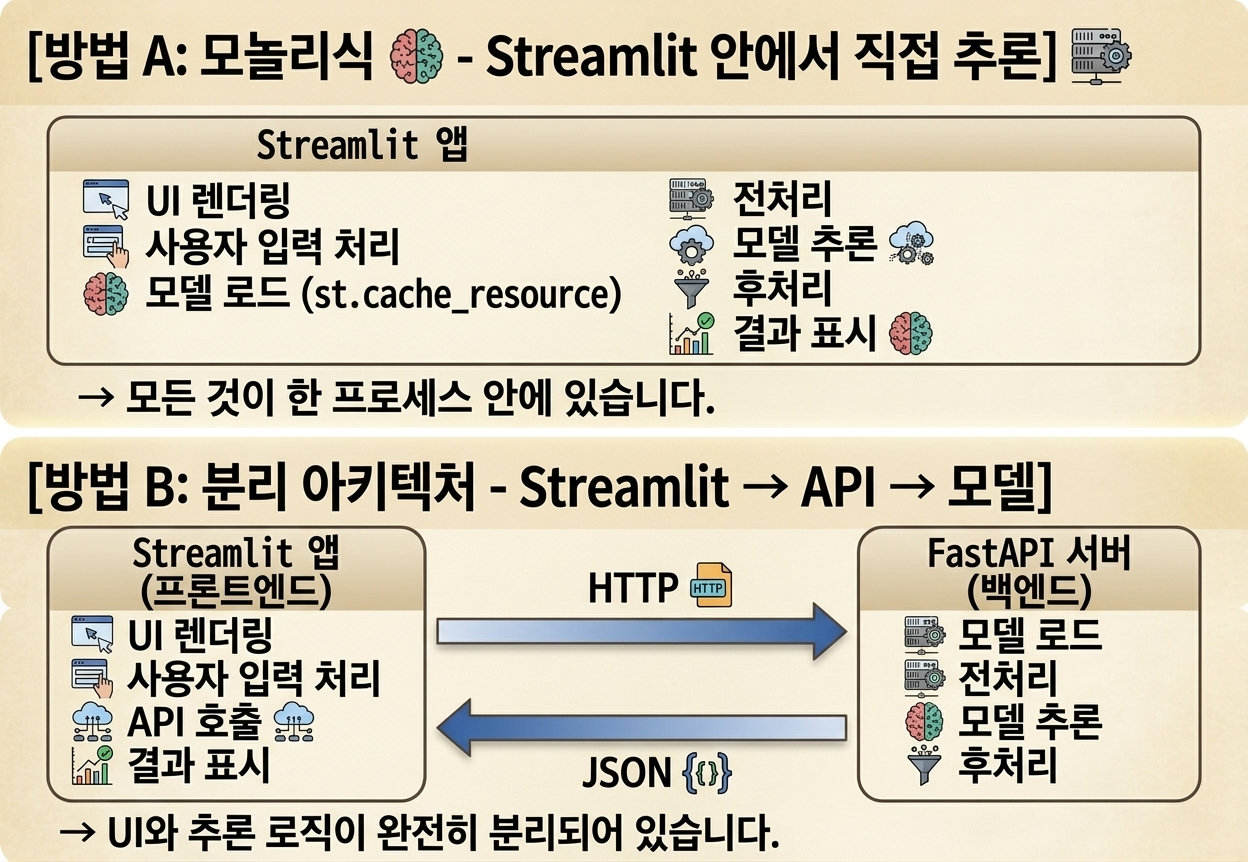


이 과정에서는 **방법 B(분리 아키텍처)**를 사용합니다.

---



### 3.2 왜 분리해야 합니까?

모놀리식이 더 간단한데 굳이 분리하는 핵심 이유 두 가지를 살펴보겠습니다.

#### 이유 1: 독립적인 개발·배포·확장

```
분리 아키텍처에서는:
  - 모델을 업데이트할 때 → FastAPI 서버만 재배포
  - UI를 변경할 때 → Streamlit 앱만 재배포
  - 사용자가 늘어서 추론 부하가 높아지면 → FastAPI만 추가 배포 (Scale-out)

모놀리식에서는:
  - 모든 변경이 앱 전체 재배포를 요구합니다.
  - 추론 부하를 처리하려면 UI까지 같이 복제해야 합니다.
```

#### 이유 2: 다양한 클라이언트 지원

```
FastAPI 서버가 독립적으로 존재하면:

  Streamlit 앱  ──▶
  모바일 앱     ──▶  FastAPI 서버  ──▶  모델 추론
  다른 서버     ──▶
  curl / 스크립트──▶

→ 하나의 API로 여러 클라이언트를 지원할 수 있습니다.
→ Streamlit은 여러 클라이언트 중 하나일 뿐입니다.
```

---

### 3.3 이 과정의 전체 아키텍처

추후 진행할 과정까지, 이 모듈에서 구축하는 시스템의 전체 구조입니다.

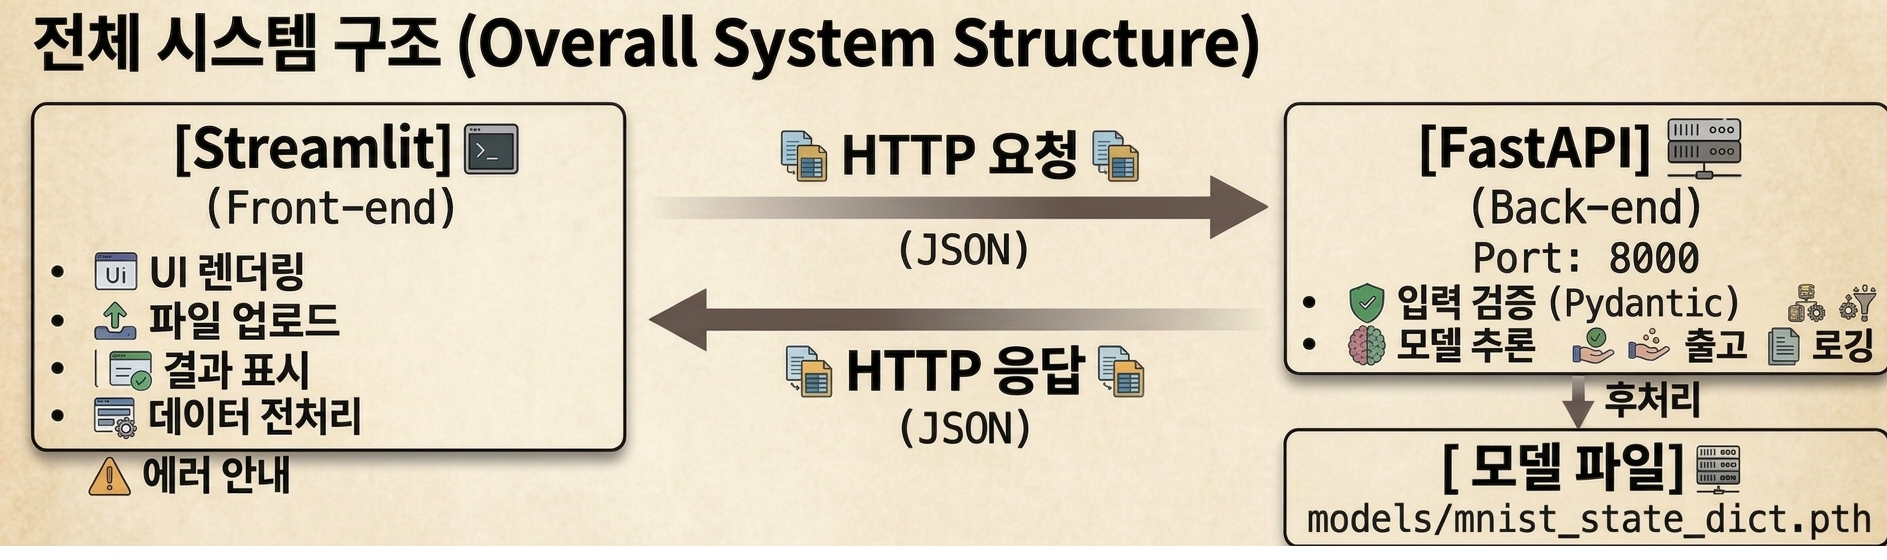



각 레이어의 역할을 정리합니다:

```
Streamlit (Frontend) — Port 8501
  역할: 사용자와의 상호작용
  담당: UI 렌더링, 파일 업로드 수신, API 호출, 결과 시각화
  기술: Streamlit

FastAPI (Backend) — Port 8000
  역할: 비즈니스 로직 처리
  담당: 입력 검증, 전처리, 모델 추론, 후처리, 에러 핸들링, 로깅
  기술: FastAPI, Pydantic, asyncio, PyTorch

모델 파일 (Storage)
  역할: 학습된 모델 가중치 저장
  담당: 직렬화된 모델 파일 (.pth, .onnx 등)
```

---

### 3.4 통신 흐름

사용자가 이미지를 업로드했을 때의 전체 흐름을 추적합니다.

```
사용자: 이미지 드래그 앤 드롭

  ① Streamlit: 파일 수신
  ② Streamlit: 이미지 → Base64 변환
  ③ Streamlit: POST http://localhost:8000/predict/image
               {"image_base64": "iVBOR...", "return_probabilities": true}
  
  ④ FastAPI: Pydantic으로 입력 검증
  ⑤ FastAPI: Base64 → PIL Image → 전처리 → 텐서
  ⑥ FastAPI: run_in_executor → model(tensor)
  ⑦ FastAPI: 후처리 → JSON 응답
               {"success": true, "predicted_class": "7", "confidence": 0.98, ...}
  
  ⑧ Streamlit: 응답 수신
  ⑨ Streamlit: 결과를 st.metric, st.bar_chart 등으로 시각화

사용자: 결과 확인 ✅
```

> 이 흐름에서 Streamlit은 **모델에 대해 아무것도 알지 못합니다.**
> PyTorch가 설치되어 있지 않아도 됩니다.
> HTTP 요청을 보내고, JSON 응답을 받아서 화면에 그릴 뿐입니다.

---

### ✅ 체크포인트

1. 모놀리식과 분리 아키텍처의 핵심 차이를 한 문장으로 설명하세요.
2. 모델을 업데이트할 때, 분리 아키텍처에서는 어떤 서버만 재배포하면 됩니까?
3. Streamlit 앱에 PyTorch가 설치되어 있지 않아도 되는 이유는 무엇입니까?

---

> **다음 섹션에서는** Streamlit에서 FastAPI를 호출하는 코드를 작성합니다.
> `requests`와 `httpx`로 HTTP 요청을 보내는 방법을 실습합니다.


## 4. Streamlit에서 FastAPI 호출하기

---

> **학습 목표**
> - `requests` 라이브러리로 Streamlit에서 FastAPI를 호출할 수 있습니다.
> - 이미지를 Base64로 변환하여 API에 전송할 수 있습니다.
> - API 호출 실패 시 사용자에게 적절한 피드백을 제공할 수 있습니다.

---

### 4.1 기본 패턴

Streamlit에서 FastAPI를 호출하는 코드는 단순합니다.



```python
import requests

# GET — 서버 상태 확인
response = requests.get("http://localhost:8000/health")
health = response.json()

# POST — 추론 요청 (Base64 이미지)
import base64

image_base64 = base64.b64encode(image_bytes).decode("utf-8")
response = requests.post(
    "http://localhost:8000/predict/image",
    json={"image_base64": image_base64, "return_probabilities": True},
)
result = response.json()
```

> Day 1에서 `requests.get()`으로 외부 API를 호출한 것과 동일합니다.
> 차이점은 호출 대상이 **우리가 만든 FastAPI 서버**라는 것뿐입니다.

---

### 4.2 에러 처리

API 호출은 실패할 수 있습니다. `try/except`로 감싸서 사용자에게 안내합니다.

```python
import streamlit as st
import requests

def call_api(url, json_data=None, method="post"):
    """API를 호출하고, 실패 시 st.error()로 안내합니다."""
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버가 실행 중인지 확인하세요.")
        return None
    except requests.exceptions.Timeout:
        st.warning("⏱️ **응답 시간 초과.** 잠시 후 다시 시도하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None
```

> 핵심 원칙: **성공 시 dict, 실패 시 None을 반환.**
> 호출 측에서 `if result:`로 간단하게 분기할 수 있습니다.

---

### ✅ 체크포인트

1. 이미지를 API에 전송할 때 Base64로 인코딩하는 이유는 무엇입니까?
2. `response.raise_for_status()`는 어떤 역할을 합니까?

---

> **다음 섹션에서는** 오늘 배운 모든 내용을 종합하여
> MNIST 추론 대시보드를 처음부터 끝까지 구현합니다.

## 5. 실습: MNIST 추론 대시보드 만들기

---


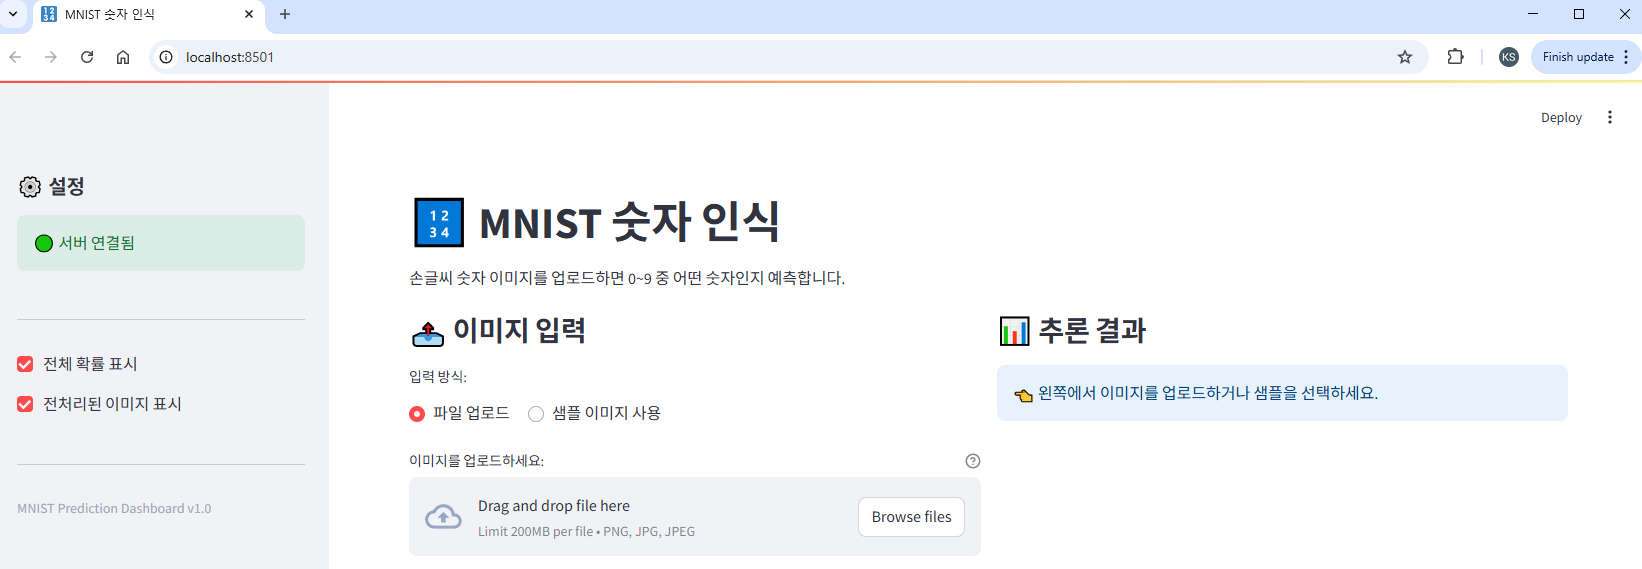


> **실습 목표**
> - MNIST 추론 대시보드를 처음부터 끝까지 구현합니다.
> - 이미지 업로드 → API 호출 → 결과 시각화의 전체 흐름을 완성합니다.
> - Day 1~4까지 배운 모든 내용이 하나의 서비스로 동작하는 것을 확인합니다.

---

### 5.1 전체 구성

```
실행해야 하는 서버: 2개

터미널 1 (백엔드):  uvicorn app.main_final:app --port 8000
터미널 2 (프론트엔드): streamlit run frontend/app_dashboard.py --server.port 8501
```

---

### 5.2 대시보드 코드 작성

백엔드는 FastAPI로, 프론트엔드는 Streamlit으로 구동되는 MNIST 추론 대시보드를 구성하는 코드를 작성합니다.  

In [5]:
%%writefile frontend/app_dashboard.py
"""
Day 4 - MNIST 추론 대시보드
FastAPI 백엔드와 연동하는 Streamlit 프론트엔드
"""
import streamlit as st
import requests
import base64
import io
from PIL import Image


# ===== 페이지 설정 =====
st.set_page_config(
    page_title="MNIST 숫자 인식",
    page_icon="🔢",
    layout="wide",
)


# ===== API 호출 함수 =====
API_BASE = "http://localhost:8000"

def call_api(url, json_data=None, method="post"):
    """API를 호출하고, 실패 시 에러 메시지를 표시합니다."""
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버가 실행 중인지 확인하세요.")
        return None
    except requests.exceptions.Timeout:
        st.warning("⏱️ **응답 시간 초과.** 잠시 후 다시 시도하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    # 서버 상태 표시
    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 서버 연결됨")
        server_ok = True
    else:
        st.error("🔴 서버 연결 실패")
        server_ok = False

    st.divider()

    # 옵션
    show_probabilities = st.checkbox("전체 확률 표시", value=True)
    show_preprocessed = st.checkbox("전처리된 이미지 표시", value=True)

    st.divider()
    st.caption("MNIST Prediction Dashboard v1.0")


# ===== 메인 영역 =====
st.title("🔢 MNIST 숫자 인식")
st.write("손글씨 숫자 이미지를 업로드하면 0~9 중 어떤 숫자인지 예측합니다.")

col_input, col_result = st.columns(2)

# ----- 입력 영역 -----
with col_input:
    st.subheader("📤 이미지 입력")

    input_method = st.radio(
        "입력 방식:", ["파일 업로드", "샘플 이미지 사용"], horizontal=True,
    )

    image_bytes = None

    if input_method == "파일 업로드":
        # 샘플 모드에서 저장한 상태를 지웁니다 (업로드 이미지에 샘플 정답이 비교되는 것 방지)
        st.session_state.pop("sample_image_bytes", None)
        st.session_state.pop("sample_caption", None)
        st.session_state.pop("sample_label", None)
        uploaded = st.file_uploader(
            "이미지를 업로드하세요:",
            type=["png", "jpg", "jpeg"],
            help="28x28 그레이스케일 권장. 다른 크기도 자동 변환됩니다.",
        )
        if uploaded:
            image_bytes = uploaded.getvalue()
            st.image(uploaded, caption="업로드된 이미지", width=200)

    else:
        st.info("보고 싶은 숫자를 고르면, MNIST 테스트셋에서 그 숫자의 손글씨를 보여줍니다.")
        digit = st.number_input("보고 싶은 숫자 (0~9):", min_value=0, max_value=9, value=1)
        variant = st.number_input("같은 숫자의 몇 번째 샘플? (0~99):", min_value=0, max_value=99, value=0)

        if st.button("샘플 이미지 로드"):
            try:
                from torchvision import datasets
                test_dataset = datasets.MNIST(root="data", train=False, download=True)
                # digit인 샘플들의 위치를 찾아 variant번째를 뽑는다 — 같은 입력이면 항상 같은 이미지
                matches = (test_dataset.targets == digit).nonzero().flatten()
                idx = int(matches[variant])
                sample_image, sample_label = test_dataset[idx]

                buffer = io.BytesIO()
                sample_image.save(buffer, format="PNG")
                # 버튼 클릭은 "그 한 번의 재실행"에서만 True입니다.
                # 이미지를 session_state에 보관해야 '추론 실행' 클릭(또 다른 재실행) 후에도 남습니다.
                st.session_state["sample_image_bytes"] = buffer.getvalue()
                st.session_state["sample_caption"] = f"숫자 {digit} — {variant}번째 샘플 (테스트셋 #{idx})"
                st.session_state["sample_label"] = sample_label
                st.session_state.pop("last_result", None)   # 이전 추론 결과가 새 샘플과 섞여 보이지 않게
            except Exception as e:
                st.error(f"샘플 로드 실패: {e}")

        # 저장된 샘플 이미지를 매 재실행마다 다시 표시합니다.
        if "sample_image_bytes" in st.session_state:
            image_bytes = st.session_state["sample_image_bytes"]
            st.image(image_bytes, caption=st.session_state["sample_caption"], width=200)

    # 전처리된 이미지 미리보기
    if image_bytes and show_preprocessed:
        st.caption("전처리된 이미지 (28x28 그레이스케일):")
        img = Image.open(io.BytesIO(image_bytes)).convert("L").resize((28, 28))
        st.image(img, width=150)


# ----- 결과 영역 -----
with col_result:
    st.subheader("📊 추론 결과")

    if image_bytes is None:
        st.info("👈 왼쪽에서 이미지를 업로드하거나 샘플을 선택하세요.")

    elif not server_ok:
        st.error("서버에 연결할 수 없습니다. 사이드바의 서버 상태를 확인하세요.")

    else:
        if st.button("🚀 추론 실행", type="primary", use_container_width=True):
            with st.spinner("모델 추론 중..."):
                # Base64 인코딩 → API 호출
                image_base64 = base64.b64encode(image_bytes).decode("utf-8")
                result = call_api(
                    f"{API_BASE}/predict/image",
                    json_data={
                        "image_base64": image_base64,
                        "return_probabilities": show_probabilities,
                    },
                )

            if result:
                st.session_state["last_result"] = result

        # 결과 표시
        if "last_result" in st.session_state:
            result = st.session_state["last_result"]

            # 메트릭
            m1, m2 = st.columns(2)
            with m1:
                st.metric(label="예측 결과", value=result["predicted_class"])
            with m2:
                st.metric(label="확신도", value=f"{result['confidence']:.1%}")

            # 확률 분포
            if result.get("probabilities"):
                st.subheader("📊 클래스별 확률 분포")
                probs = result["probabilities"]
                for cls in sorted(probs.keys(), key=lambda x: int(x)):
                    prob = probs[cls]
                    c1, c2 = st.columns([1, 5])
                    with c1:
                        is_pred = cls == result["predicted_class"]
                        st.write(f"**{'👉 ' if is_pred else ''}{cls}**")
                    with c2:
                        st.progress(float(prob), text=f"{prob:.2%}")

            # 샘플 이미지인 경우 정답 비교
            if "sample_label" in st.session_state:
                label = st.session_state["sample_label"]
                if result["predicted_class"] == str(label):
                    st.success(f"✅ 정답! (정답: {label})")
                else:
                    st.error(f"❌ 오답 (정답: {label}, 예측: {result['predicted_class']})")


Overwriting frontend/app_dashboard.py


---

### 5.3 실행 및 테스트

#### Step 1: 백엔드 서버 실행

> ⚠️ **Day 4부터 바로 시작했거나, 로컬에서 DP04만 연 경우**
>
> 백엔드(`app/main_final.py`)는 Day 1~3에서 만든 파일입니다. 파일이 없으면
> `Could not import module "app.main_final"` 오류가 납니다.
> 아래 셀을 실행하면 없는 파일만 자동으로 만들어 줍니다. (이미 있으면 그대로 둡니다)

In [6]:
# Day 1~3에서 만든 백엔드 파일을 확인하고, 없으면 새로 만듭니다.
# (Day 4부터 바로 시작하거나, 로컬에서 DP04만 연 경우에 필요합니다)
import os

for _d in ('app', 'models', 'data'):
    os.makedirs(_d, exist_ok=True)

BACKEND_FILES = {}

BACKEND_FILES["app/model_utils.py"] = r'''import torch
import torch.nn as nn
from torchvision import transforms

class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

CLASS_NAMES = [str(i) for i in range(10)]

def load_model(model_path, num_classes=10):
    model = SimpleClassifier(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.eval()
    return model

def predict(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        idx = probs.argmax().item()
        return {
            "predicted_class": CLASS_NAMES[idx],
            "confidence": round(probs[idx].item(), 4),
            "probabilities": {CLASS_NAMES[i]: round(probs[i].item(), 4) for i in range(len(CLASS_NAMES))},
        }
'''

BACKEND_FILES["app/schemas.py"] = r'''from pydantic import BaseModel, Field, field_validator
from typing import Optional

class PixelPredictRequest(BaseModel):
    pixels: list[list[float]] = Field(..., description="28x28 픽셀 배열")
    return_probabilities: bool = Field(default=False)
    @field_validator("pixels")
    @classmethod
    def validate_pixels(cls, v):
        if len(v) != 28:
            raise ValueError(f"28행이어야 합니다. 현재: {len(v)}행")
        for i, row in enumerate(v):
            if len(row) != 28:
                raise ValueError(f"각 행은 28열이어야 합니다. {i}번째 행: {len(row)}열")
        return v

class ImagePredictRequest(BaseModel):
    image_base64: str = Field(..., min_length=1)
    return_probabilities: bool = Field(default=False)

class PredictResponse(BaseModel):
    success: bool = Field(description="성공 여부")
    predicted_class: str = Field(description="예측 숫자 (0~9)")
    confidence: float = Field(description="확신도", ge=0.0, le=1.0)
    probabilities: Optional[dict[str, float]] = Field(default=None)
'''

BACKEND_FILES["app/logger_config.py"] = r'''"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger'''

BACKEND_FILES["app/error_handlers.py"] = r'''"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )'''

BACKEND_FILES["app/middleware.py"] = r'''"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response'''

BACKEND_FILES["app/main_final.py"] = r'''"""
Day 3 최종 버전 - 비동기 + 에러 핸들링 + 로깅
"""
import io
import base64
import asyncio
from concurrent.futures import ThreadPoolExecutor

import torch
import numpy as np
from PIL import Image
from fastapi import FastAPI, HTTPException

from app.schemas import PixelPredictRequest, ImagePredictRequest, PredictResponse
from app.model_utils import load_model, predict, preprocess
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


logger = setup_logger("ml_api")

app = FastAPI(
    title="MNIST Prediction API",
    description="비동기 처리, 에러 핸들링, 로깅이 적용된 MNIST 추론 API",
    version="3.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="inference")

MODEL_PATH = "models/mnist_state_dict.pth"
model = None


@app.on_event("startup")
async def startup():
    global model
    logger.info(f"모델 로드 중: {MODEL_PATH}")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")


def run_inference(image_tensor: torch.Tensor) -> dict:
    """별도 스레드에서 실행되는 추론 함수"""
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, image_tensor)


@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if model is not None else "loading",
        "model_loaded": model is not None,
    }


@app.get("/model/info", tags=["System"])
async def model_info():
    from app.model_utils import CLASS_NAMES
    total_params = sum(p.numel() for p in model.parameters())
    return {
        "model_name": "SimpleClassifier",
        "model_path": MODEL_PATH,
        "num_classes": len(CLASS_NAMES),
        "classes": CLASS_NAMES,
        "total_parameters": total_params,
    }


@app.post("/predict/pixels", response_model=PredictResponse, tags=["Inference"])
async def predict_from_pixels(request: PixelPredictRequest):
    try:
        pixel_array = np.array(request.pixels, dtype=np.float32)
        pixel_tensor = torch.from_numpy(pixel_array)
        pixel_tensor = (pixel_tensor - 0.1307) / 0.3081
        pixel_tensor = pixel_tensor.unsqueeze(0).unsqueeze(0)
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"전처리 실패: {str(e)}")

    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(inference_executor, run_inference, pixel_tensor)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return PredictResponse(
        success=True,
        predicted_class=result["predicted_class"],
        confidence=result["confidence"],
        probabilities=result["probabilities"] if request.return_probabilities else None,
    )


@app.post("/predict/image", response_model=PredictResponse, tags=["Inference"])
async def predict_from_image(request: ImagePredictRequest):
    try:
        image_bytes = base64.b64decode(request.image_base64)
        image = Image.open(io.BytesIO(image_bytes))
        image_tensor = preprocess(image).unsqueeze(0)
    except base64.binascii.Error:
        raise HTTPException(status_code=400, detail="유효하지 않은 Base64 문자열입니다.")
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"이미지 처리 실패: {str(e)}")

    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(inference_executor, run_inference, image_tensor)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return PredictResponse(
        success=True,
        predicted_class=result["predicted_class"],
        confidence=result["confidence"],
        probabilities=result["probabilities"] if request.return_probabilities else None,
    )'''

for _path, _body in BACKEND_FILES.items():
    if os.path.exists(_path):
        print(f"✅ {_path} 있음")
    else:
        print(f"⚠️ {_path} 없음 → 생성합니다.")
        with open(_path, "w", encoding="utf-8") as f:
            f.write(_body)

MODEL_PATH = "models/mnist_state_dict.pth"
CANDIDATES = [
    "../DP03/models/mnist_state_dict.pth",
    "../DP02/models/mnist_state_dict.pth",
]
if os.path.exists(MODEL_PATH):
    print(f"✅ {MODEL_PATH} 있음")
else:
    copied = False
    import shutil
    for src in CANDIDATES:
        if os.path.exists(src):
            shutil.copy2(src, MODEL_PATH)
            print(f"✅ 모델을 복사했습니다: {src} → {MODEL_PATH}")
            copied = True
            break
    if not copied:
        print("⚠️ 모델 파일 없음 → MNIST 모델을 학습합니다. (약 1~2분 소요)")
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torchvision import datasets, transforms
        from torch.utils.data import DataLoader
        from app.model_utils import SimpleClassifier

        _tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        _train = DataLoader(datasets.MNIST("data", train=True, download=True, transform=_tf), batch_size=64, shuffle=True)

        _model = SimpleClassifier(10)
        _opt = optim.Adam(_model.parameters(), lr=1e-3)
        _crit = nn.CrossEntropyLoss()
        _model.train()
        for _epoch in range(2):
            for _i, (_x, _y) in enumerate(_train):
                _opt.zero_grad()
                _loss = _crit(_model(_x), _y)
                _loss.backward()
                _opt.step()
                if (_i + 1) % 300 == 0:
                    print(f"  Epoch {_epoch+1}, Batch {_i+1}/{len(_train)}, Loss: {_loss.item():.4f}")
        torch.save(_model.state_dict(), MODEL_PATH)
        print(f"  ✅ {MODEL_PATH} 생성 완료")

print("\n🎉 백엔드 준비 완료. 아래 셀에서 서버를 실행하세요.")

✅ app/model_utils.py 있음
✅ app/schemas.py 있음
✅ app/logger_config.py 있음
✅ app/error_handlers.py 있음
✅ app/middleware.py 있음
✅ app/main_final.py 있음
✅ models/mnist_state_dict.pth 있음

🎉 백엔드 준비 완료. 아래 셀에서 서버를 실행하세요.


In [7]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main_final:app", port=8000)

/Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP03/.venv/lib/python3.12/site-packages/fastapi/applications.py:18: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  from fastapi.exception_handlers import (
/Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP03/.venv/lib/python3.12/site-packages/fastapi/applications.py:30: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  from fastapi.openapi.utils import get_openapi
Exception in thread Thread-4 (_run):
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_4/Frameworks/Python.framework/Versions/3.12/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_4/Frameworks/Python.framework/Versions/3.12/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwa

서버가 시작되지 않았습니다. 위 로그를 확인하세요.


#### Step 2: 프론트엔드 실행

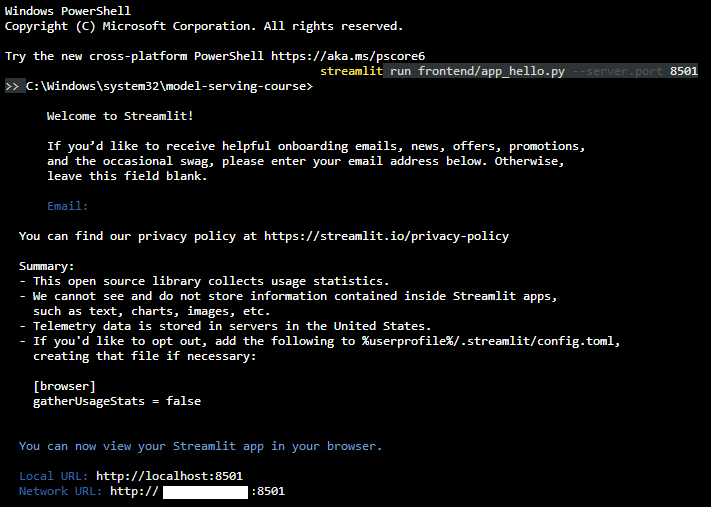

아래는 터미널에서 실행하는 명령입니다. 노트북 셀에서 직접 실행하면 셀이 끝나지 않으니, 바로 아래의 백그라운드 실행 셀을 사용하세요.

```bash
# 별도 터미널에서 실행합니다
cd 06_Deployment/DP04
streamlit run frontend/app_dashboard.py --server.port 8501
```

In [8]:
# Streamlit은 .venv에 설치되어 있으면 pip를 건너뜁니다.
import importlib.util
import sys
import subprocess
import time
import socket
import contextlib
import tempfile
import os
import webbrowser

try:
    from google.colab import output as _colab_output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if importlib.util.find_spec("streamlit") is None:
    print("Streamlit 미설치 → 지금 설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "streamlit"])
else:
    print("Streamlit 이미 설치됨")

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 포트가 열릴 때까지 확인합니다."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):
        print(f"♻️  이미 실행 중 (포트 {port})")
        return None

    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    extra = []
    if IN_COLAB:
        extra = [
            "--server.enableCORS", "false",
            "--server.enableXsrfProtection", "false",
        ]

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true",
         *extra],
        stdout=log, stderr=subprocess.STDOUT,
    )
    for _ in range(60):
        if proc.poll() is not None:
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            url = f"http://localhost:{port}"
            print(f"✅ 프론트엔드: {url}")
            print(f"   (로그: {log_path})")
            if not IN_COLAB:
                webbrowser.open(url)
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print("❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_dashboard.py", port=8501)

Streamlit 이미 설치됨
✅ 프론트엔드: http://localhost:8501
   (로그: /var/folders/pz/kxyvptf55r59t4ktwsn_rhfc0000gn/T/streamlit_8501.log)


#### Step 3: 노트북에서 바로 확인

Colab에서는 대시보드를 노트북 iframe으로 띄웁니다.  
로컬(Mac)에서는 `http://localhost:8501` 을 브라우저에서 엽니다.

> ⚠️ **화면이 비어 있거나 계속 로딩만 된다면**
> - Step 2 셀이 `✅`를 출력했는지 먼저 확인하세요.
> - 로컬에서는 Jupyter iframe 대신 브라우저 탭을 사용하세요.
> - 대시보드 안의 서버 상태가 🔴이면 Step 1의 백엔드 셀을 다시 실행하세요.

In [9]:
def show_dashboard(port=8501, height=900):
    """실행 중인 프론트엔드를 엽니다. Colab은 iframe, 로컬은 브라우저."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if not port_open(port):
        print(f"⚠️ 포트 {port}에 프론트엔드가 없습니다. Step 2 셀을 먼저 실행하세요.")
        return

    if IN_COLAB:
        from google.colab import output
        print(f"✅ 대시보드를 아래에 띄웁니다 (Colab 프록시 → 포트 {port})")
        output.serve_kernel_port_as_iframe(port, height=str(height))
    else:
        import webbrowser
        url = f"http://localhost:{port}"
        print(f"✅ 브라우저에서 엽니다: {url}")
        webbrowser.open(url)

show_dashboard(port=8501, height=900)

✅ 브라우저에서 엽니다: http://localhost:8501


#### Step 4: 테스트 시나리오

```
브라우저(http://localhost:8501) 또는 Colab iframe에서 바로 조작합니다.

[테스트 1] 기본 흐름
  1. 사이드바에서 서버 상태가 🟢인지 확인
  2. "샘플 이미지 사용" → 보고 싶은 숫자 1 → "샘플 이미지 로드"
  3. "🚀 추론 실행" 클릭
  4. 예측 숫자, 확신도, 확률 분포가 표시되는지 확인

[테스트 2] 파일 업로드
  1. "파일 업로드" 선택 → 아무 이미지 드래그 앤 드롭
  2. "🚀 추론 실행" → 결과 확인

[테스트 3] 에러 상황
  1. 백엔드 서버를 종료 — 노트북 새 셀에서 stop_server(8000) 실행
  2. 사이드바 상태가 🔴으로 변하는지 확인
  3. 다시 살리려면 serve_in_thread("app.main_final:app", port=8000)
```

이미지 입력 후

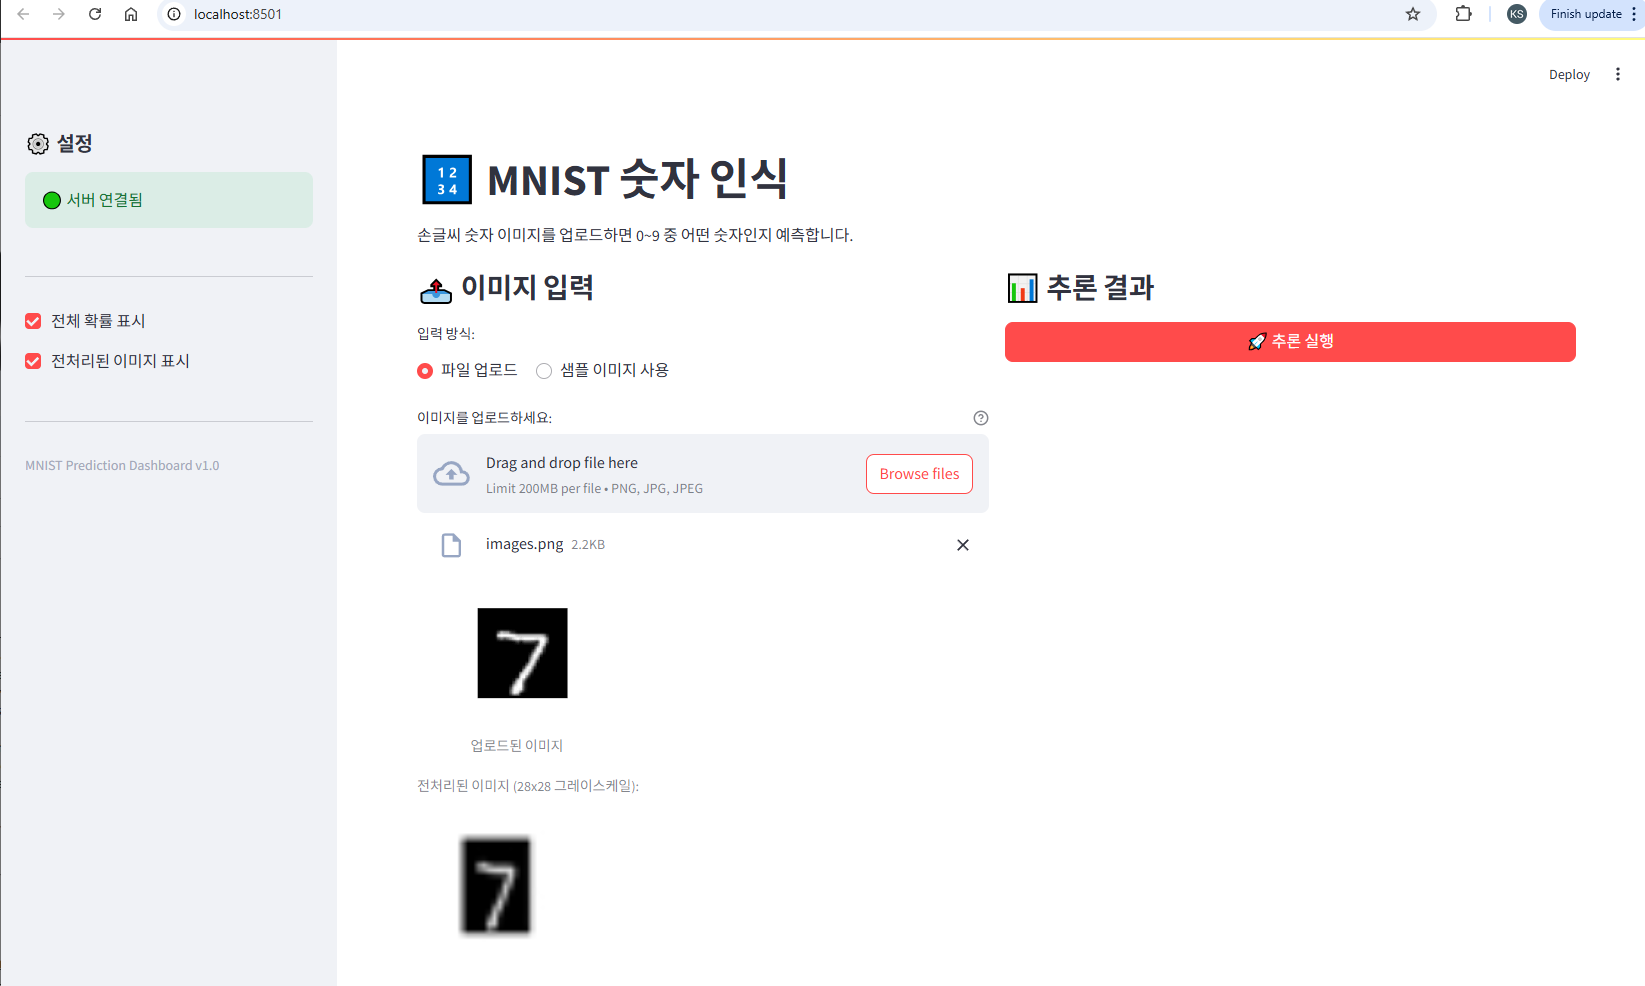

추론실행 버튼을 누르면 결과가 출력됩니다.   
우리의 모델이 3 epoch만 학습이 되어서 일을 잘 못하지만, streamlit으로 만든 front 페이지는 훌륭하게 동작합니다!  

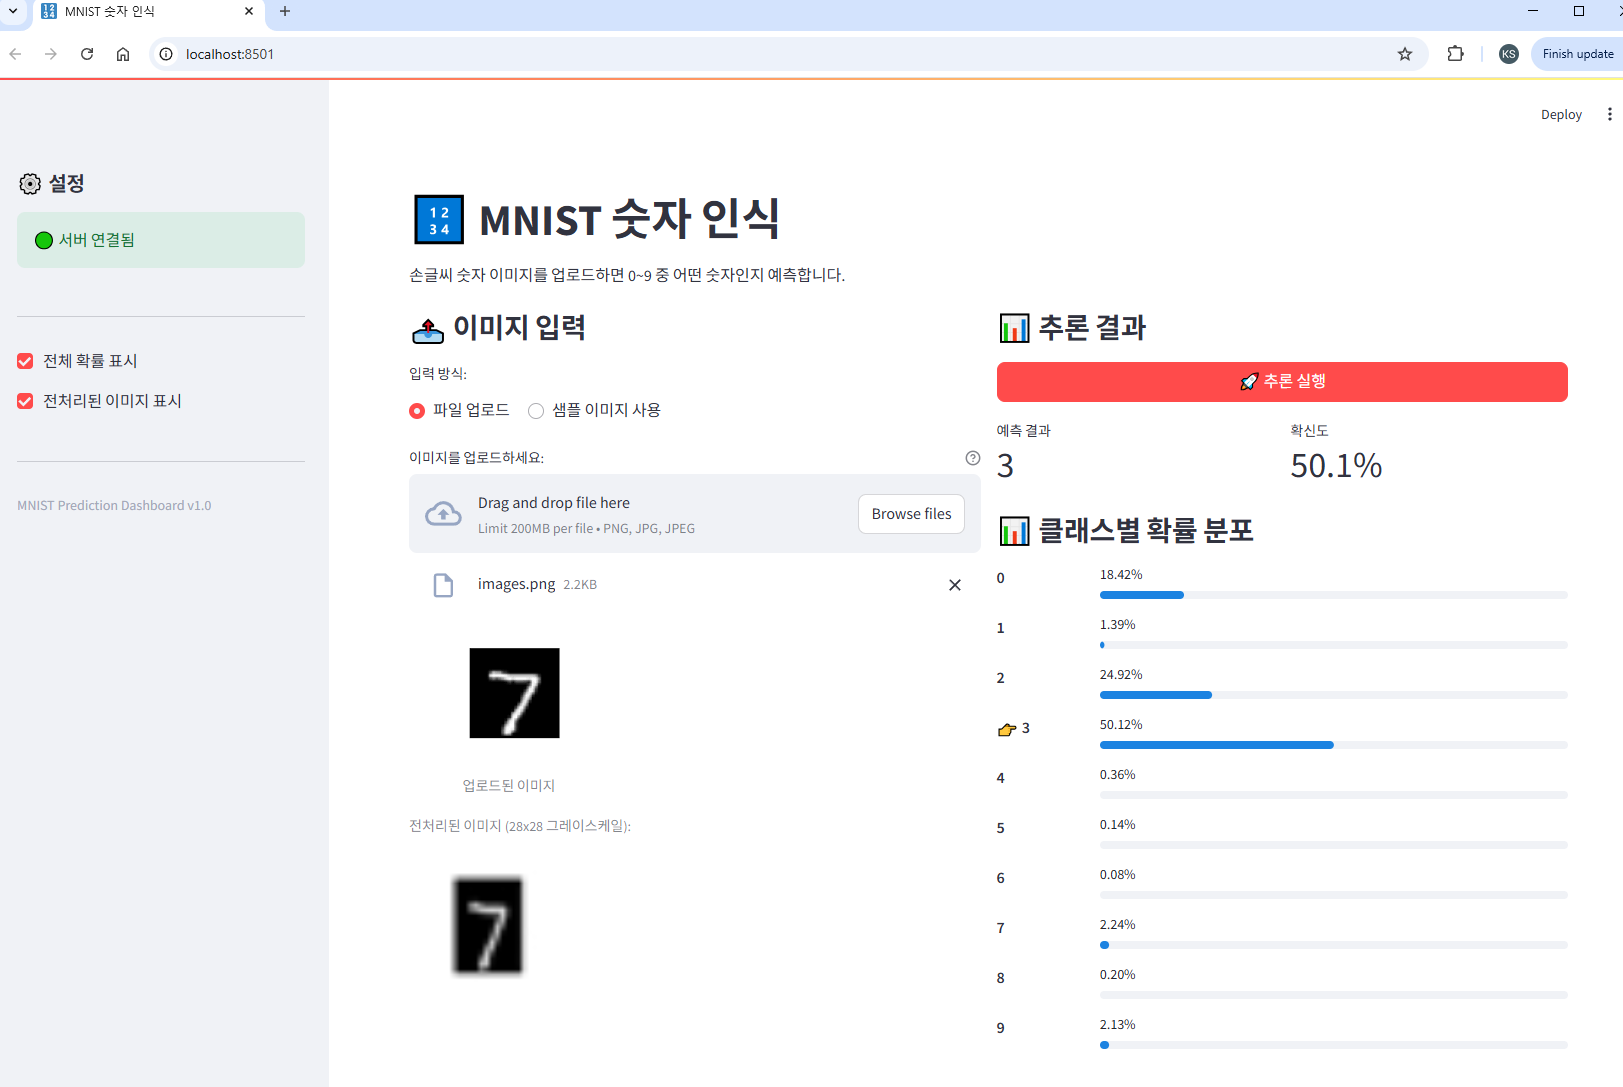

샘플 데이터로 테스트 해보실 수도 있습니다.  

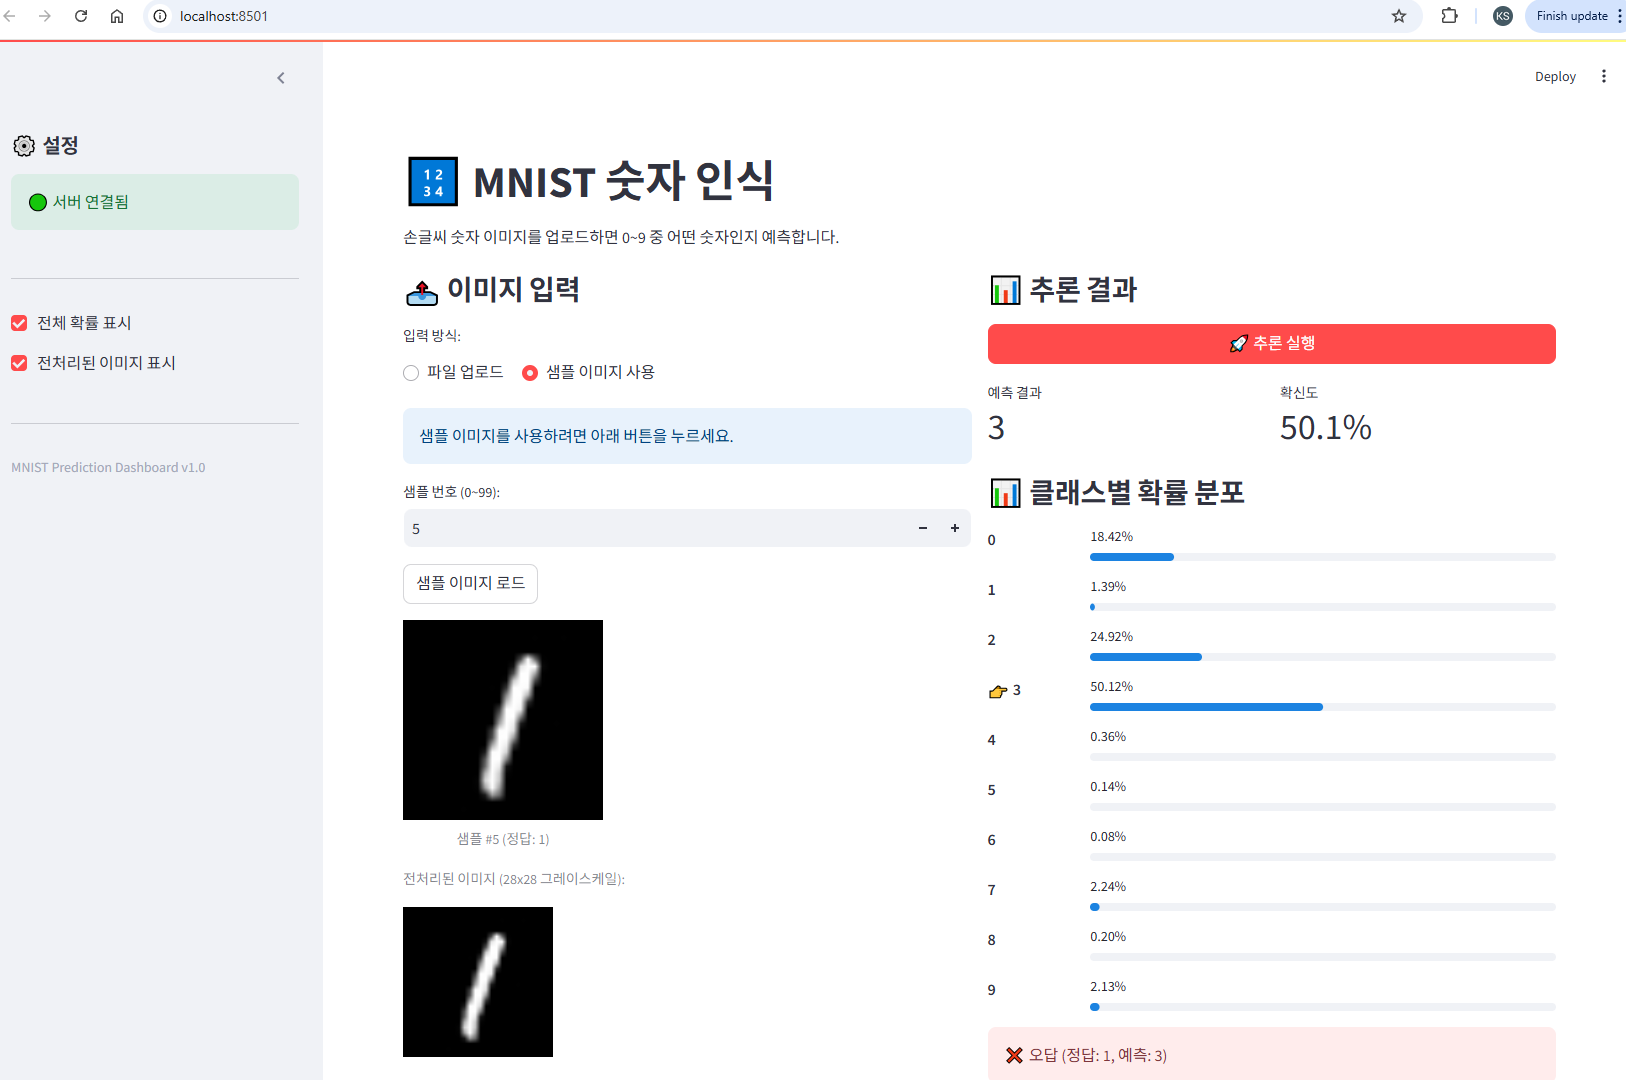

---

### 5.4 대시보드 코드 해부

대시보드에서 사용한 핵심 패턴을 정리합니다.

```
패턴                     코드                              용도
──────────────────────────────────────────────────────────────────
API 호출                 call_api(url, json_data)          FastAPI와 통신
Base64 인코딩            base64.b64encode(bytes)           이미지를 JSON에 담기
에러 처리                try/except → st.error()           실패 시 사용자 안내
상태 유지                st.session_state["last_result"]   재실행 시 결과 유지
사이드바                 with st.sidebar:                  설정/옵션 배치
컬럼 레이아웃            col1, col2 = st.columns(2)        입력/결과 나란히
메트릭 표시              st.metric(label, value)           예측 결과 강조
확률 바                  st.progress(value, text)          확률 분포 시각화
```

> `st.session_state`를 사용하는 이유:
> Streamlit은 버튼을 누를 때마다 스크립트를 재실행합니다.
> 결과를 `session_state`에 저장하지 않으면, 재실행 시 결과가 사라집니다.

---

### 5.5 프로젝트 구조 확인

```
model-serving-course/
├── 📁 app/                              ← 백엔드 (FastAPI)
│   ├── error_handlers.py                ← Day 3
│   ├── logger_config.py                 ← Day 3
│   ├── main_final.py                    ← Day 3
│   ├── middleware.py                    ← Day 3
│   ├── model_utils.py                   ← Day 1
│   └── schemas.py                       ← Day 2
├── 📁 frontend/                          ← 프론트엔드 (Streamlit)
│   └── app_dashboard.py                 ← Day 4: 대시보드
├── 📁 models/
│   └── mnist_state_dict.pth
├── .gitignore
└── requirements.txt
```

> Day 2~3에서 만들었던 `api_client.py`, `ui_helpers.py` 등 별도 모듈 없이,
> 대시보드 파일 하나로 완결됩니다.
> 코드가 커지면 Day 5 프로젝트에서 모듈 분리를 도입합니다.

---

### ✅ Day 4 최종 체크포인트

```
[섹션 1: Streamlit 소개]
Q1. Streamlit의 스크립트 재실행 모델이란?

[섹션 2: 핵심 컨셉]
Q2. @st.cache_resource를 사용하는 이유는?

[섹션 3: System Architecture]
Q3. 프론트엔드와 백엔드를 분리하는 핵심 이유 두 가지는?
Q4. Streamlit 앱에 PyTorch가 필요 없는 이유는?

[섹션 4: API 호출]
Q5. API 호출 실패 시 사용자에게 스택 트레이스가 아닌 메시지를 보여줘야 하는 이유는?

[섹션 5: 실습]
Q6. st.session_state에 결과를 저장하는 이유는?
Q7. 이미지를 API로 전달할 때 Base64 인코딩이 필요한 이유는?
```

---

### 📌 Day 4 요약

```
오늘 한 일:
  ✅ Streamlit의 기본 개념과 실행 모델을 이해했습니다.
  ✅ 프론트엔드-백엔드 분리 아키텍처의 이유와 구조를 이해했습니다.
  ✅ Streamlit에서 FastAPI를 호출하고 에러를 처리하는 패턴을 익혔습니다.
  ✅ MNIST 추론 대시보드를 완성했습니다.

내일 할 일 (Day 5 — 프로젝트 1):
  🔜 정형 데이터 기반 예측 서비스를 처음부터 끝까지 구축합니다.
  🔜 Day 1~4의 모든 기술을 하나의 프로젝트에 통합합니다.
```

---

> **마치며**
>
> 지금까지 MNIST라는 예제 데이터셋으로 연습했습니다.  
> 다음 시간은 **정형 데이터(CSV)** 를 사용하는 새로운 예측 모델로
> 전체 파이프라인을 **처음부터 끝까지** 직접 구축합니다.  

### 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 섹션 5 수행내역 캡쳐  
4. 각 섹션 체크포인트의 답변

수고하셨습니다!